In [98]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload

import torch
from detector_dev.utils import run_ring_sim_variable_cfm,Bando_OVM_FTL
from Adversaries.controllers.car_following_adversarial import ACC_Benign

import detector_dev.utils as utils
import Data_Processing.sim_processing_utils as sim_processing_utils
from Data_Processing.sim_processing_utils import get_trajectory_timeseries
from Detectors.Deep_Learning.AutoEncoders.utils import *
from Detectors.Deep_Learning.AutoEncoders.utils import get_loss_filter_indiv as loss_smooth

from copy import deepcopy
import ray
import sys
import csv

In [74]:
FIGURE_SIZE = [35,10]
TITLE_FONTSIZE = 40
LABEL_FONTSIZE = 40
TICK_FONTSIZE = 35

# Load impact data:

Finished.


(5.0, 7.0)

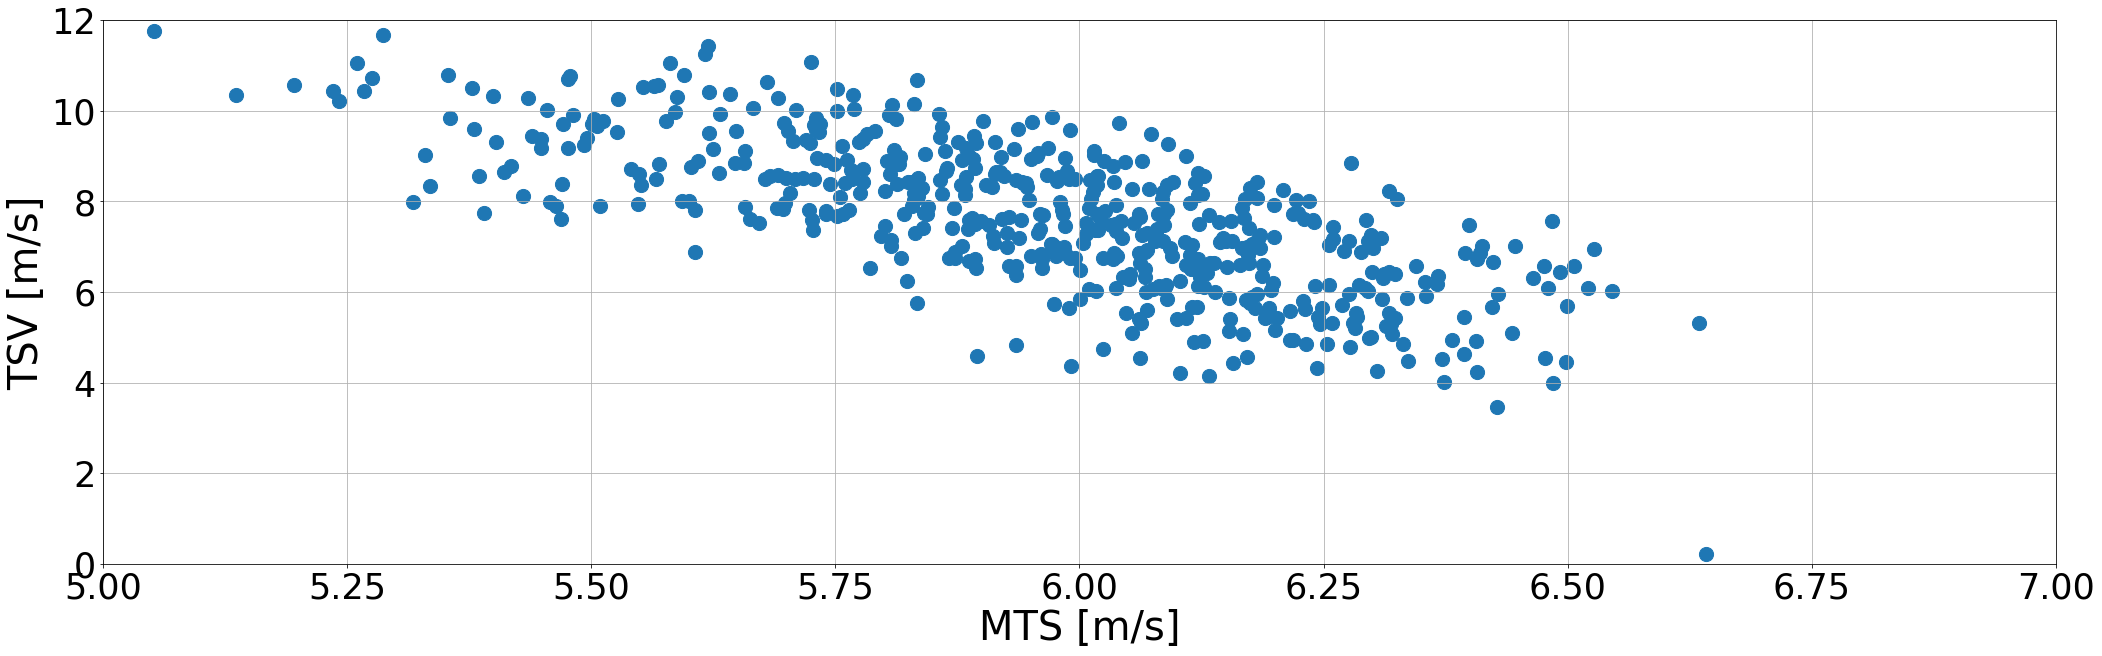

In [111]:
impacts_list_single_lane = np.loadtxt('performance_metrics_single_lane.csv',delimiter=',',dtype=str)

sim_names_SL_list = []
MTS_vals_SL_list = []
TSV_vals_SL_list = []

for data in impacts_list_single_lane:
    sim_names_SL_list.append(data[0][22:])
    MTS_vals_SL_list.append(float(data[1]))
    TSV_vals_SL_list.append(float(data[2]))
print('Finished.')

plt.figure(figsize=FIGURE_SIZE)
plt.scatter(MTS_vals_SL_list,TSV_vals_SL_list,s=200)
_ = plt.ylabel('TSV [m/s]',fontsize=LABEL_FONTSIZE)
_ = plt.xlabel('MTS [m/s]',fontsize=LABEL_FONTSIZE)
_ = plt.yticks(fontsize=TICK_FONTSIZE)
_ = plt.xticks(fontsize=TICK_FONTSIZE)
plt.grid()
plt.ylim([0,12])
plt.xlim([5,7])

Finished.


(5.0, 7.0)

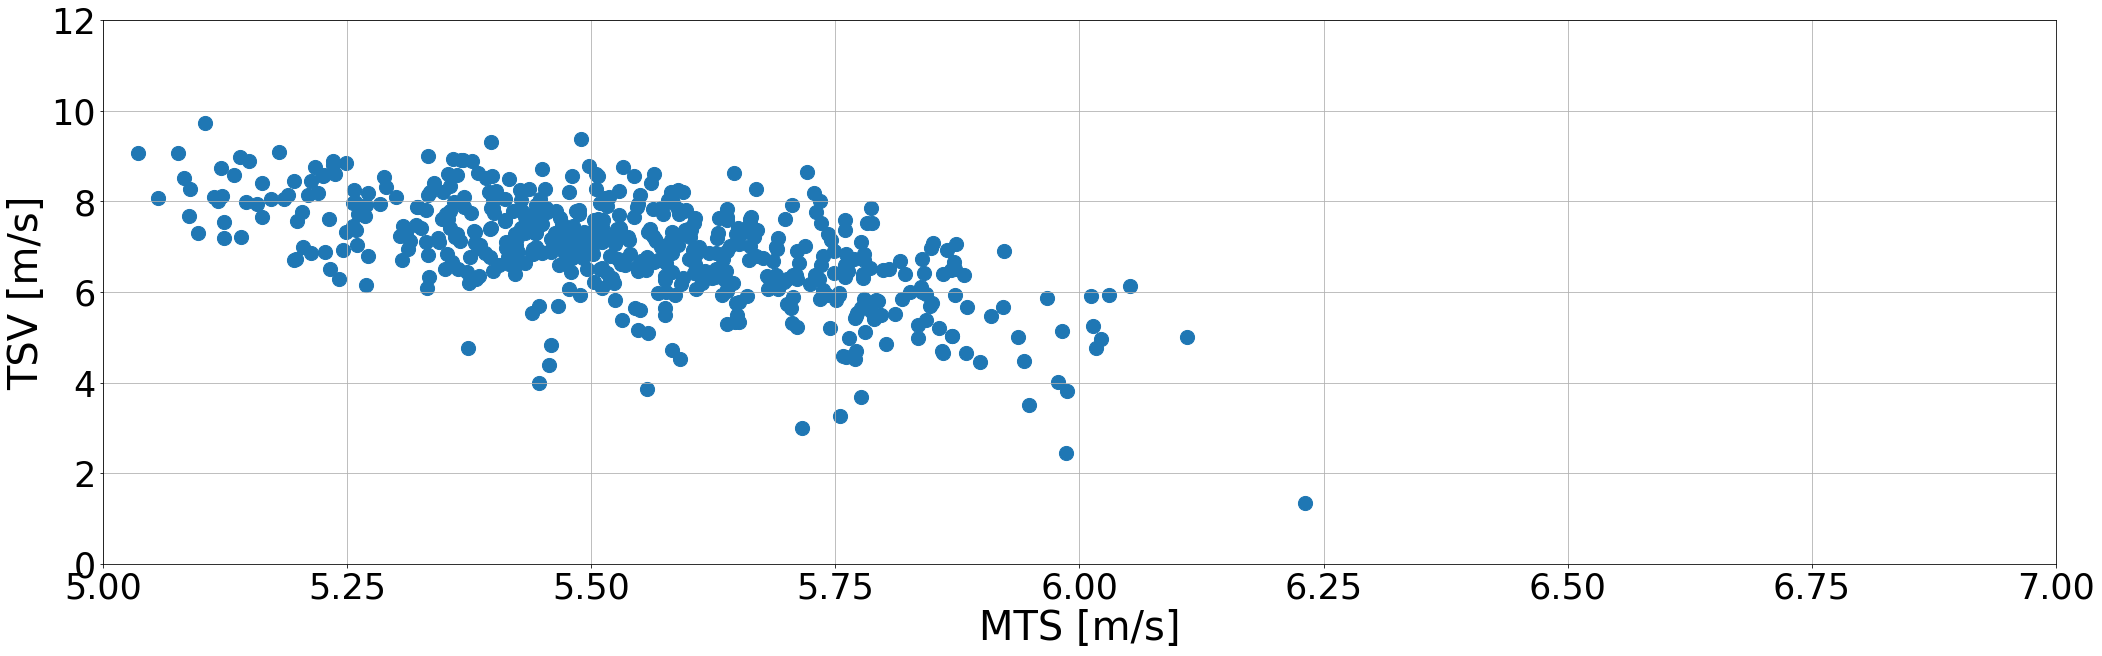

In [110]:
impacts_list_double_lane = np.loadtxt('performance_metrics_double_lane.csv',delimiter=',',dtype=str)

sim_names_DL_list = []
MTS_vals_DL_list = []
TSV_vals_DL_list = []

for data in impacts_list_double_lane:
    sim_names_DL_list.append(data[0][22:])
    MTS_vals_DL_list.append(float(data[1]))
    TSV_vals_DL_list.append(float(data[2]))
print('Finished.')

plt.figure(figsize=FIGURE_SIZE)
plt.scatter(MTS_vals_DL_list,TSV_vals_DL_list,s=200)
_ = plt.ylabel('TSV [m/s]',fontsize=LABEL_FONTSIZE)
_ = plt.xlabel('MTS [m/s]',fontsize=LABEL_FONTSIZE)
_ = plt.yticks(fontsize=TICK_FONTSIZE)
_ = plt.xticks(fontsize=TICK_FONTSIZE)
plt.grid()
plt.ylim([0,12])
plt.xlim([5,7])

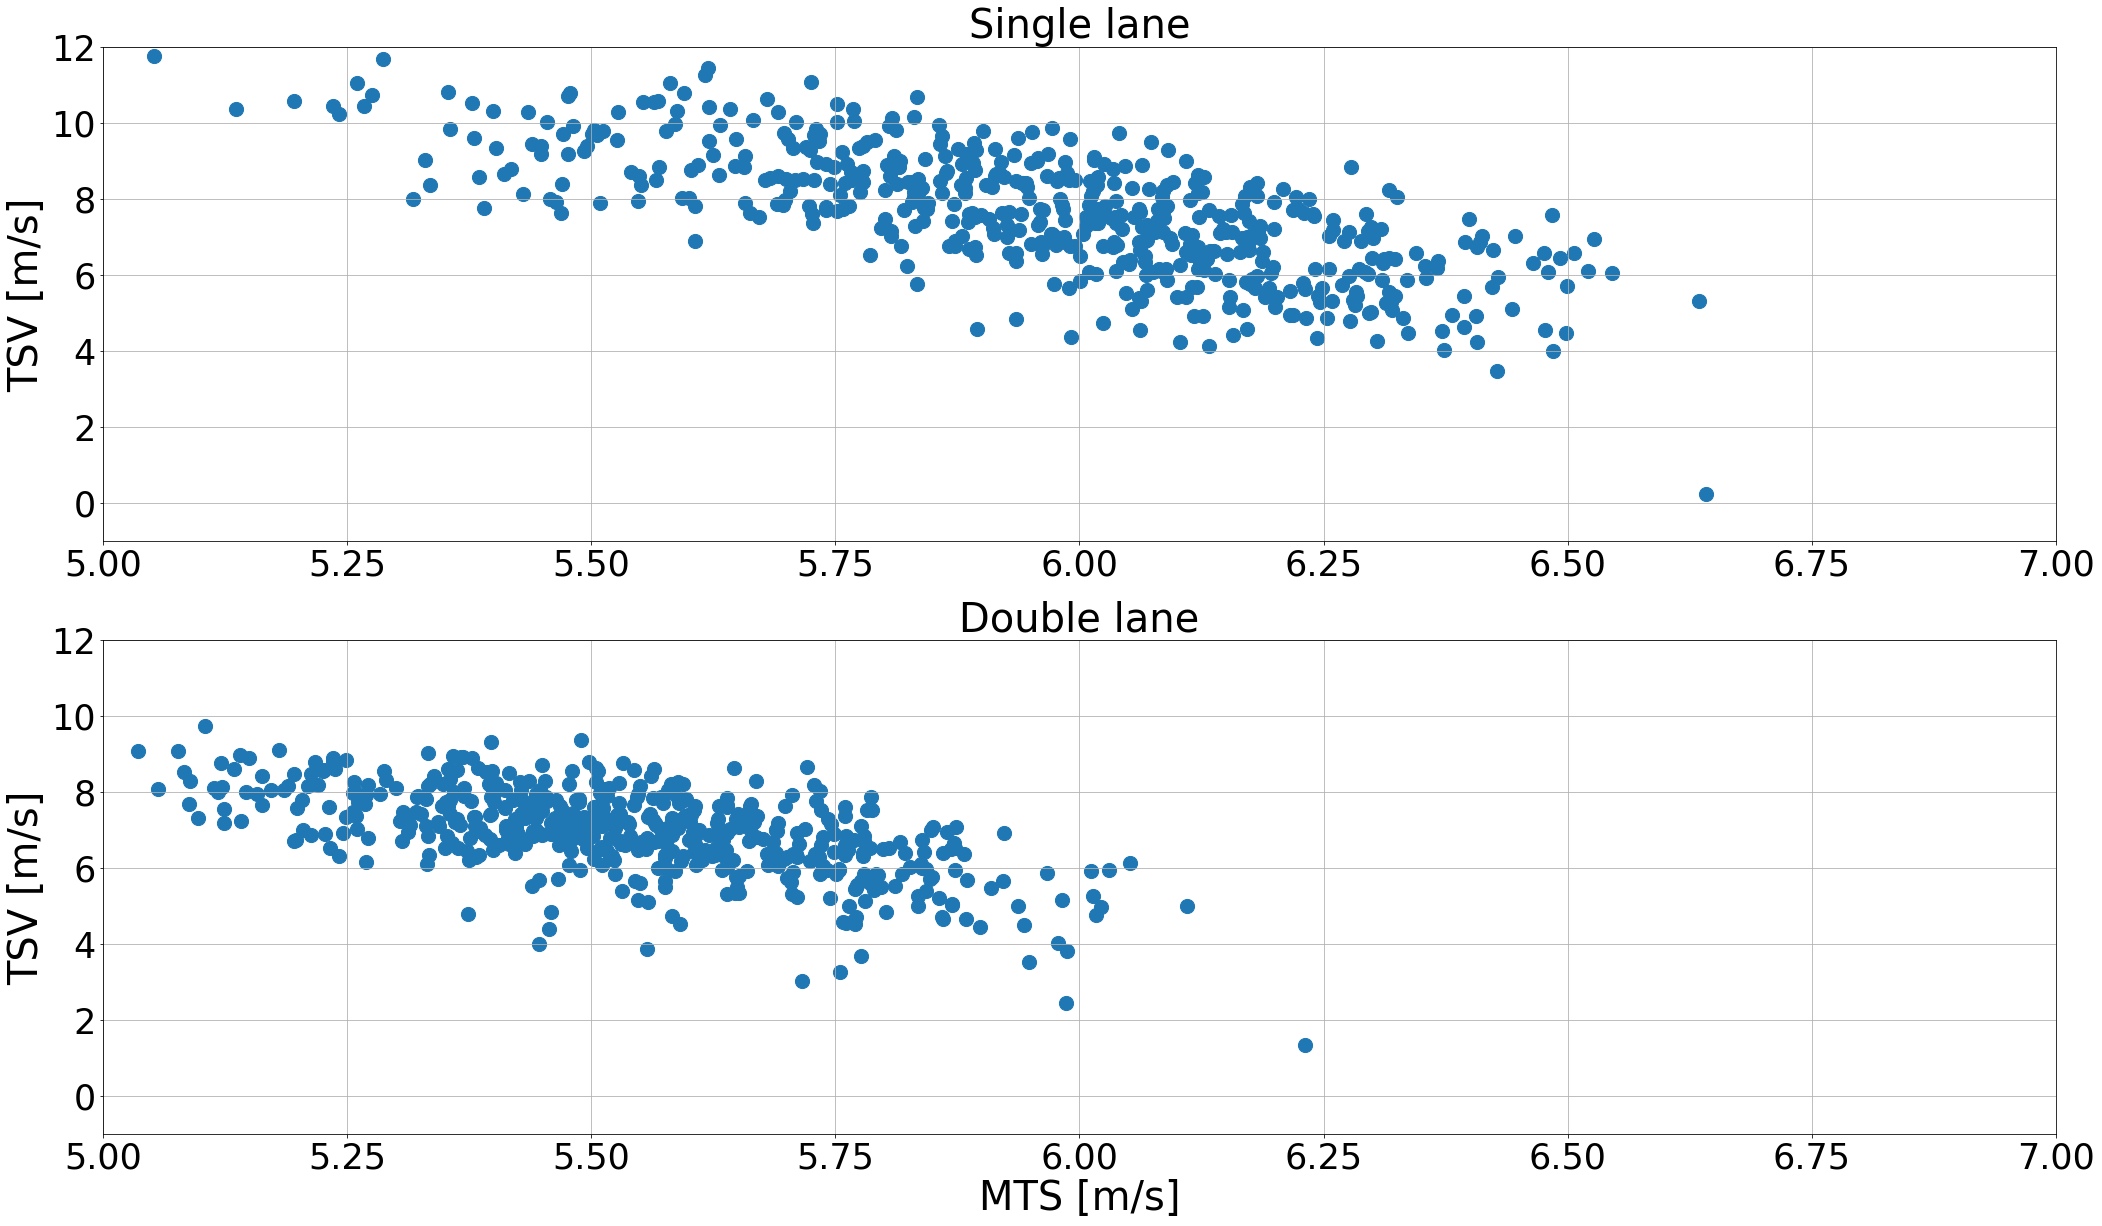

In [97]:
#FIGURE_SIZE = [35,10]
plt.figure(figsize=[35,20])



plt.subplot(2,1,1)
plt.scatter(MTS_vals_SL_list,TSV_vals_SL_list,s=200)
_ = plt.ylabel('TSV [m/s]',fontsize=LABEL_FONTSIZE)
# _ = plt.xlabel('MTS [m/s]',fontsize=LABEL_FONTSIZE)
_ = plt.yticks(fontsize=TICK_FONTSIZE)
_ = plt.xticks(fontsize=TICK_FONTSIZE)
plt.grid()
plt.ylim([-1.0,12])
plt.xlim([5,7])
_ = plt.title('Single lane',fontsize=LABEL_FONTSIZE)

plt.subplot(2,1,2)
plt.scatter(MTS_vals_DL_list,TSV_vals_DL_list,s=200)
_ = plt.ylabel('TSV [m/s]',fontsize=LABEL_FONTSIZE)
_ = plt.xlabel('MTS [m/s]',fontsize=LABEL_FONTSIZE)
_ = plt.yticks(fontsize=TICK_FONTSIZE)
_ = plt.xticks(fontsize=TICK_FONTSIZE)
plt.grid()
plt.ylim([-1.0,12])
plt.xlim([5,7])
_ = plt.title('Double lane',fontsize=LABEL_FONTSIZE)

# Load detection model:

In [4]:
# Load in a trained model:
model = get_cnn_lstm_ae_model(n_features=4)
MODEL_PATH = '/Users/vanderbilt/Desktop/General_research_tools/Anti-Flow/detector_dev/models/cnn_lstm_ae_ringlength600_1lane__1.0percentGPS.pt'
model.load_state_dict(torch.load(MODEL_PATH,map_location=torch.device('cpu')))

<All keys matched successfully>

# Load rec errors:

In [135]:
rec_error_repo_SL_path = '/Volumes/My Passport for Mac/single_lane_ring_road_attack_parameter_sweep/rec_errors'


rec_error_repo_DL_path = '/Volumes/My Passport for Mac/double_lane_ring_road_attack_parameter_sweep/rec_errors'

In [136]:
rec_error_files_SL = os.listdir(rec_error_repo_SL_path)

rec_error_files_DL = os.listdir(rec_error_repo_DL_path)

In [137]:
rec_error_file_SL_paths = []
for file in rec_error_files_SL:
    if('csv' in file):
        rec_error_file_SL_paths.append(os.path.join(rec_error_repo_SL_path,file))

rec_error_file_DL_paths = []
for file in rec_error_files_DL:
    if('csv' in file):
        rec_error_file_DL_paths.append(os.path.join(rec_error_repo_DL_path,file))

In [138]:
for i in range(len(sim_names_SL_list)):
    if(sim_names_SL_list[i] not in rec_error_file_SL_paths[i]):
        print(i)
        
for i in range(len(sim_names_DL_list)):
    if(sim_names_DL_list[i] not in rec_error_file_DL_paths[i]):
        print(i)

In [139]:
def get_sim_identifier(sim_name):
    i = 0
    while sim_name[i] != 'v': i+=1
    return sim_name[:i-1]
print(get_sim_identifier(sim_names_DL_list[0]))

TAD_0.0_ADR_-0.25


In [118]:
def get_MpVRE_with_label(MpVRE_list):
    MpVRE_with_label = []
    
    for MpVRE in MpVRE_list:
        curr_RE = float(MpVRE[1])
        is_mal = 'RDA' in MpVRE[0]
        MpVRE_with_label.append([curr_RE,is_mal])
    
    return MpVRE_with_label

# Get performance/stealth values by sim:

In [143]:
sim_performance_and_stealth_SL_dict = {}

for i,file_path in enumerate(rec_error_file_SL_paths):
    # Get simulation naming info:
    sim_name = sim_names_SL_list[i]
    sim_name_key = get_sim_identifier(sim_name[:-4])
    
    
    # Load the MpVRE values:
    RE_data = np.loadtxt(file_path,delimiter=',',dtype=str)
    MTS = MTS_vals_SL_list[i]
    TSV = TSV_vals_SL_list[i]
    if(sim_name_key not in sim_performance_and_stealth_SL_dict.keys()):
        sim_performance_and_stealth_SL_dict[sim_name_key] = {}
    
    MpVRE_with_label = get_MpVRE_with_label(RE_data)
    

    # for a particular simulation:
    sim_performance_and_stealth_SL_dict[sim_name_key][sim_name] = MpVRE_with_label

    
sim_performance_and_stealth_DL_dict = {}

for i,file_path in enumerate(rec_error_file_DL_paths):
    # Get simulation naming info:
    sim_name = sim_names_DL_list[i]
    sim_name_key = get_sim_identifier(sim_name[:-4])
    
    
    # Load the MpVRE values:
    RE_data = np.loadtxt(file_path,delimiter=',',dtype=str)
    MTS = MTS_vals_DL_list[i]
    TSV = TSV_vals_DL_list[i]
    if(sim_name_key not in sim_performance_and_stealth_DL_dict.keys()):
        sim_performance_and_stealth_DL_dict[sim_name_key] = {}
    
    MpVRE_with_label = get_MpVRE_with_label(RE_data)
    

    # for a particular simulation:
    sim_performance_and_stealth_DL_dict[sim_name_key][sim_name] = MpVRE_with_label
    
print('Finished.')

Finished.


In [145]:
def get_mean_benign_RE(RE_list):
    mean_RE = 0.0
    num_benign_samples = 0
    
    for RE in RE_list:
        if(not RE[1]):
            mean_RE += RE[0]
            num_benign_samples += 1
    
    return mean_RE/num_benign_samples


get_mean_benign_RE(sim_performance_and_stealth_DL_dict['TAD_10.0_ADR_-0.25']['TAD_10.0_ADR_-0.25_ver_1.csv'])

67.6818592941498

In [149]:
def get_max_benign_RE(RE_list):
    max_RE = 0.0
    
    for RE in RE_list:
        if(not RE[1]):
            if(RE[0] > max_RE):
                max_RE = RE[0]
    
    return max_RE

get_max_benign_RE(sim_performance_and_stealth_DL_dict['TAD_0.0_ADR_-0.25']['TAD_0.0_ADR_-0.25_ver_1.csv'])

247.2799363708496

In [159]:
def get_max_RE(RE_list):
    max_RE = 0.0
    
    for RE in RE_list:
        if(RE[0] > max_RE):
            max_RE = RE[0]
    
    return max_RE

get_max_RE(sim_performance_and_stealth_SL_dict['TAD_0.0_ADR_-0.25']['TAD_0.0_ADR_-0.25_ver_1.csv'])

99.92330890231662

In [163]:
max_RE_no_attacks_SL = []
for sim_name in sim_names_SL_list:
    sim_name_key = get_sim_identifier(sim_name[:-4])
    if('TAD_0.0' in sim_name):
        max_RE_val = get_max_RE(sim_performance_and_stealth_SL_dict[sim_name_key][sim_name])
        max_RE_no_attacks_SL.append([sim_name,max_RE_val])
        
max_RE_no_attacks_DL = []
for sim_name in sim_names_DL_list:
    sim_name_key = get_sim_identifier(sim_name[:-4])
    if('TAD_0.0' in sim_name):
        max_RE_val = get_max_RE(sim_performance_and_stealth_DL_dict[sim_name_key][sim_name])
        max_RE_no_attacks_DL.append([sim_name,max_RE_val])

In [165]:
max_RE_no_attacks_DL

[['TAD_0.0_ADR_-0.25_ver_1.csv', 247.2799363708496],
 ['TAD_0.0_ADR_-0.25_ver_10.csv', 161.95206146240236],
 ['TAD_0.0_ADR_-0.25_ver_2.csv', 182.58165344238282],
 ['TAD_0.0_ADR_-0.25_ver_3.csv', 161.45488555908204],
 ['TAD_0.0_ADR_-0.25_ver_4.csv', 220.89771438598632],
 ['TAD_0.0_ADR_-0.25_ver_5.csv', 274.6282069194748],
 ['TAD_0.0_ADR_-0.25_ver_6.csv', 195.3505094909668],
 ['TAD_0.0_ADR_-0.25_ver_7.csv', 164.32789245605468],
 ['TAD_0.0_ADR_-0.25_ver_8.csv', 211.6492660522461],
 ['TAD_0.0_ADR_-0.25_ver_9.csv', 240.31042556762696],
 ['TAD_0.0_ADR_-0.5_ver_1.csv', 159.89035858154296],
 ['TAD_0.0_ADR_-0.5_ver_10.csv', 190.05454818725585],
 ['TAD_0.0_ADR_-0.5_ver_2.csv', 192.65575958251952],
 ['TAD_0.0_ADR_-0.5_ver_3.csv', 218.9082501220703],
 ['TAD_0.0_ADR_-0.5_ver_4.csv', 225.96849761962892],
 ['TAD_0.0_ADR_-0.5_ver_5.csv', 207.88796997070312],
 ['TAD_0.0_ADR_-0.5_ver_6.csv', 151.2214697265625],
 ['TAD_0.0_ADR_-0.5_ver_7.csv', 193.27642059326172],
 ['TAD_0.0_ADR_-0.5_ver_8.csv', 161.8120

In [189]:
def get_mal_REs(RE_list):
    mal_RE_list = []
    
    for RE in RE_list:
        if(RE[1]):
            mal_RE_list.append(RE[0])
    
    return mal_RE_list

#get_mal_REs(sim_performance_and_stealth_DL_dict['TAD_0.0_ADR_-0.25']['TAD_0.0_ADR_-0.25_ver_1.csv'])


def get_ben_REs(RE_list):
    ben_RE_list = []
    
    for RE in RE_list:
        if(not RE[1]):
            ben_RE_list.append(RE[0])
    
    return ben_RE_list

#get_ben_REs(sim_performance_and_stealth_DL_dict['TAD_0.0_ADR_-0.25']['TAD_0.0_ADR_-0.25_ver_1.csv'])


In [190]:
mal_REs_with_MTS_SL = []

ben_REs_with_MTS_SL = []


for i,sim_name in enumerate(sim_names_SL_list):
    sim_name_key = get_sim_identifier(sim_name[:-4])
    MTS_val = MTS_vals_SL_list[i]
    mal_REs = get_mal_REs(sim_performance_and_stealth_SL_dict[sim_name_key][sim_name])
    
    for RE in mal_REs:
        mal_REs_with_MTS_SL.append([MTS_val,RE])
          
    ben_REs = get_ben_REs(sim_performance_and_stealth_SL_dict[sim_name_key][sim_name])
    for RE in ben_REs:
        ben_REs_with_MTS_SL.append([MTS_val,RE])
        
mal_REs_with_MTS_DL = []

ben_REs_with_MTS_DL = []

for i,sim_name in enumerate(sim_names_DL_list):
    sim_name_key = get_sim_identifier(sim_name[:-4])
    MTS_val = MTS_vals_DL_list[i]
    mal_REs = get_mal_REs(sim_performance_and_stealth_DL_dict[sim_name_key][sim_name])
    
    for RE in mal_REs:
        mal_REs_with_MTS_DL.append([MTS_val,RE])
        
    ben_REs = get_ben_REs(sim_performance_and_stealth_DL_dict[sim_name_key][sim_name])
    for RE in ben_REs:
        ben_REs_with_MTS_DL.append([MTS_val,RE])
        
        
print('Finished.')

Finished.


In [191]:
mal_REs_with_MTS_SL = np.array(mal_REs_with_MTS_SL)
ben_REs_with_MTS_SL = np.array(ben_REs_with_MTS_SL)

mal_REs_with_MTS_DL = np.array(mal_REs_with_MTS_DL)
ben_REs_with_MTS_DL = np.array(ben_REs_with_MTS_DL)

In [177]:
threshold_SL = 0.0
for max_RE_val in max_RE_no_attacks_SL:
    if(max_RE_val[1] > threshold_SL):
        threshold_SL = max_RE_val[1]
        
threshold_DL = 0.0
for max_RE_val in max_RE_no_attacks_DL:
    if(max_RE_val[1] > threshold_DL):
        threshold_DL = max_RE_val[1]

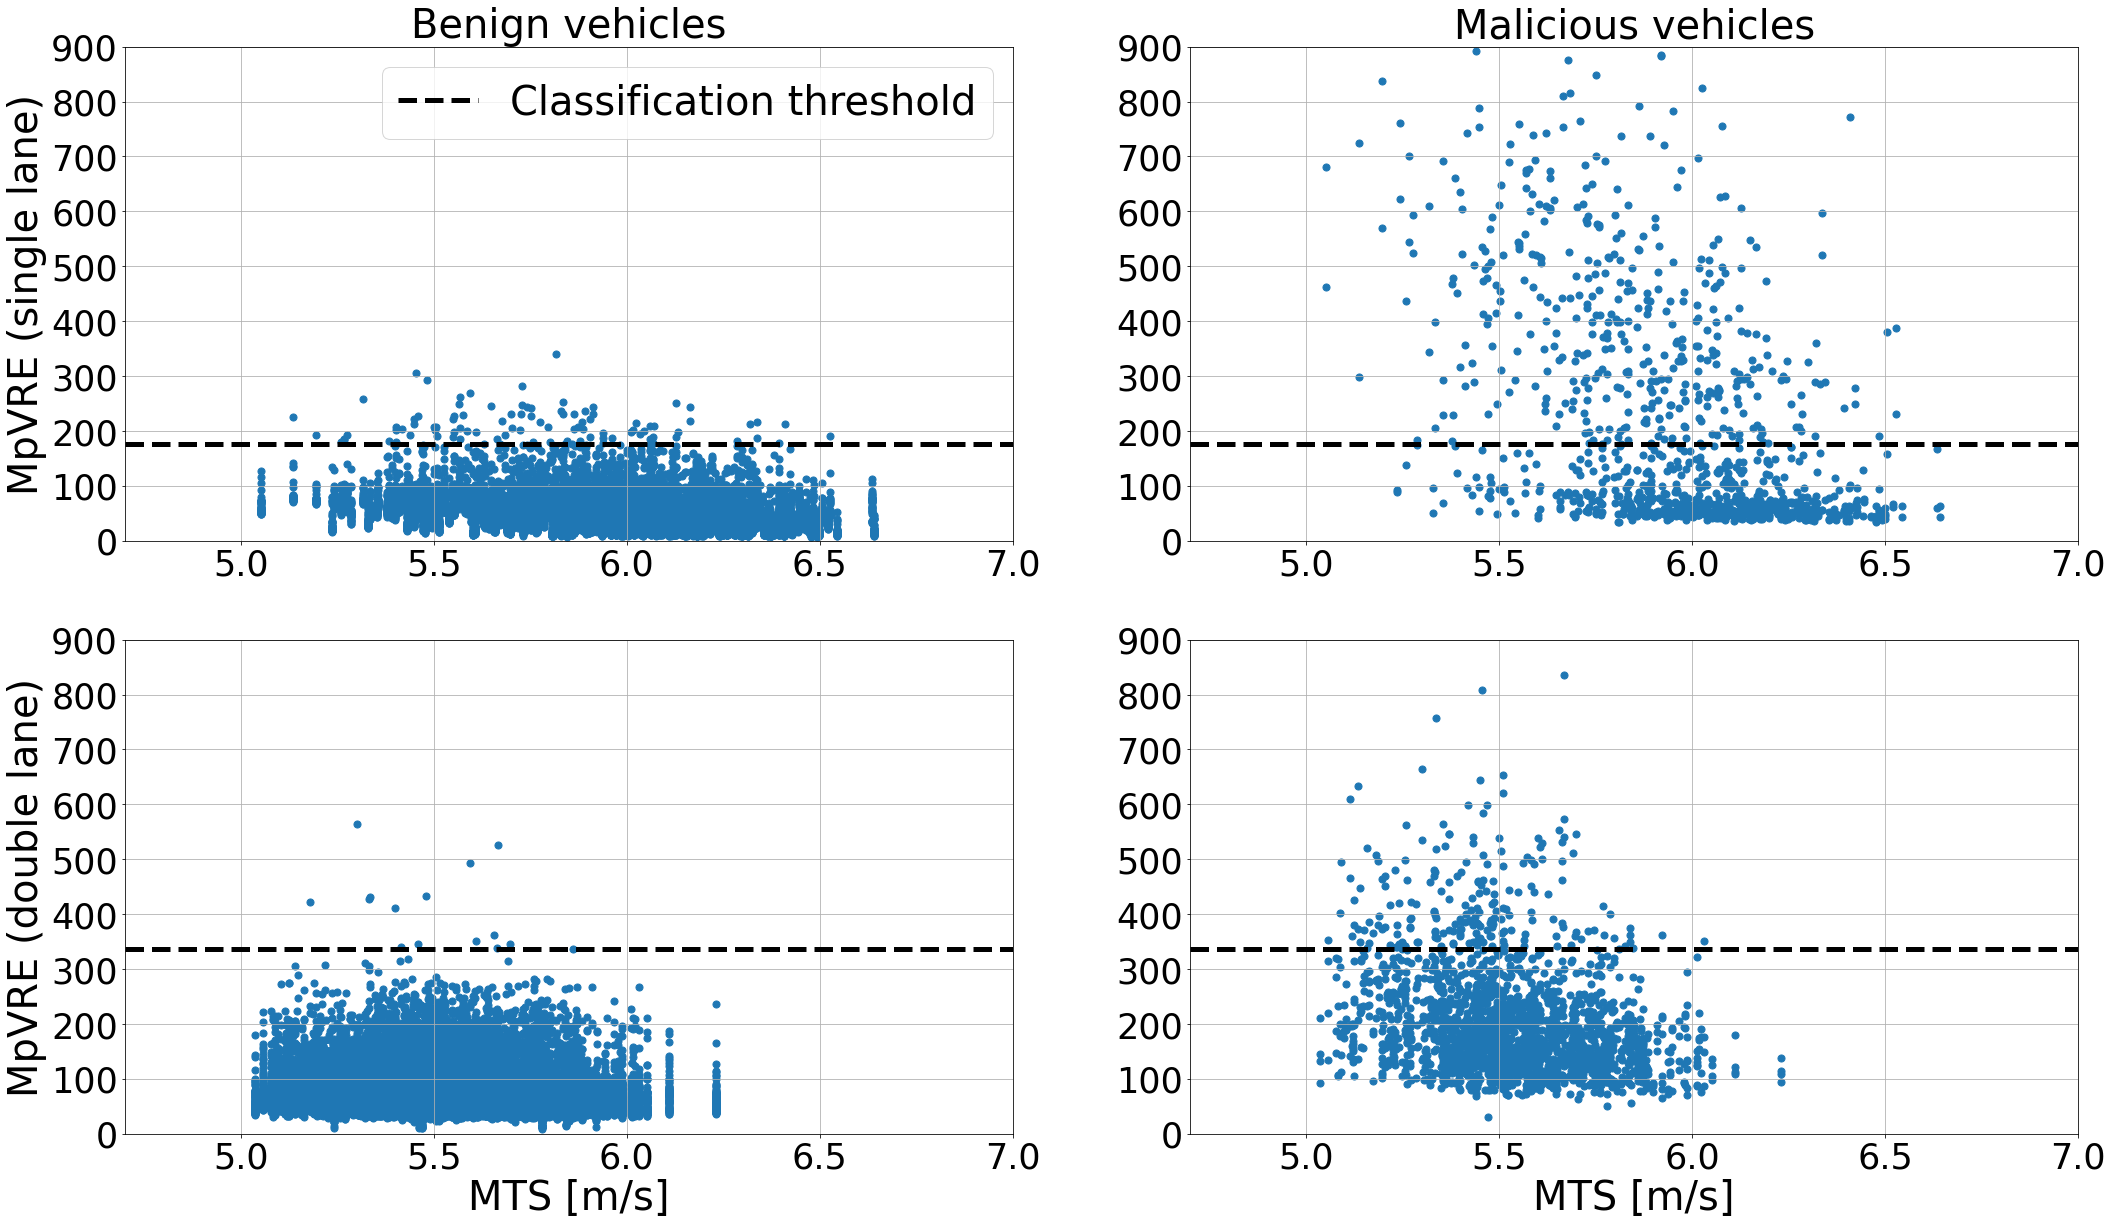

In [195]:
plt.figure(figsize=[35,20])


dotsize=50
linewidth=5.0


plt.subplot(2,2,1)

# x = MTS_vals_SL_list
# y = []

# for sim_name in sim_names_SL_list:
#     sim_name_key = get_sim_identifier(sim_name[:-4])
#     mean_benign_RE = get_max_benign_RE(sim_performance_and_stealth_SL_dict[sim_name_key][sim_name])
#     y.append(mean_benign_RE)

    
x = ben_REs_with_MTS_SL[:,0]
y = ben_REs_with_MTS_SL[:,1]
    
plt.scatter(x,y,s=dotsize)
plt.plot([4.7,7],[threshold_SL,threshold_SL],'k--',linewidth=linewidth,label='Classification threshold')
_ = plt.ylabel('MpVRE (single lane)',fontsize=LABEL_FONTSIZE)
# _ = plt.xlabel('MTS [m/s]',fontsize=LABEL_FONTSIZE)
_ = plt.yticks(fontsize=TICK_FONTSIZE)
_ = plt.xticks(fontsize=TICK_FONTSIZE)
plt.grid()
plt.ylim([0.0,900])
plt.xlim([4.7,7])
_ = plt.title('Benign vehicles',fontsize=LABEL_FONTSIZE)
_ = plt.legend(fontsize=LABEL_FONTSIZE)

plt.subplot(2,2,2)
plt.scatter(mal_REs_with_MTS_SL[:,0],mal_REs_with_MTS_SL[:,1],s=dotsize)
plt.plot([4.7,7],[threshold_SL,threshold_SL],'k--',linewidth=linewidth)
plt.grid()
_ = plt.yticks(fontsize=TICK_FONTSIZE)
_ = plt.xticks(fontsize=TICK_FONTSIZE)
plt.ylim([0.0,900])
plt.xlim([4.7,7])

_ = plt.title('Malicious vehicles',fontsize=LABEL_FONTSIZE)


# x = MTS_vals_DL_list
# y = []
# for sim_name in sim_names_DL_list:
#     sim_name_key = get_sim_identifier(sim_name[:-4])
#     mean_benign_RE = get_max_benign_RE(sim_performance_and_stealth_DL_dict[sim_name_key][sim_name])
#     y.append(mean_benign_RE)

    
x = ben_REs_with_MTS_DL[:,0]
y = ben_REs_with_MTS_DL[:,1]
    
plt.subplot(2,2,3)
plt.scatter(x,y,s=dotsize)
plt.plot([4.7,7.0],[threshold_DL,threshold_DL],'k--',linewidth=linewidth)
_ = plt.ylabel('MpVRE (double lane)',fontsize=LABEL_FONTSIZE)
_ = plt.xlabel('MTS [m/s]',fontsize=LABEL_FONTSIZE)
_ = plt.yticks(fontsize=TICK_FONTSIZE)
_ = plt.xticks(fontsize=TICK_FONTSIZE)
plt.grid()
plt.ylim([0.0,900])
plt.xlim([4.7,7])



plt.subplot(2,2,4)
plt.scatter(mal_REs_with_MTS_DL[:,0],mal_REs_with_MTS_DL[:,1],s=dotsize)
plt.plot([4.7,7.0],[threshold_DL,threshold_DL],'k--',linewidth=linewidth)
plt.grid()
_ = plt.yticks(fontsize=TICK_FONTSIZE)
_ = plt.xticks(fontsize=TICK_FONTSIZE)
plt.ylim([0.0,900])
plt.xlim([4.7,7])
_ = plt.xlabel('MTS [m/s]',fontsize=LABEL_FONTSIZE)

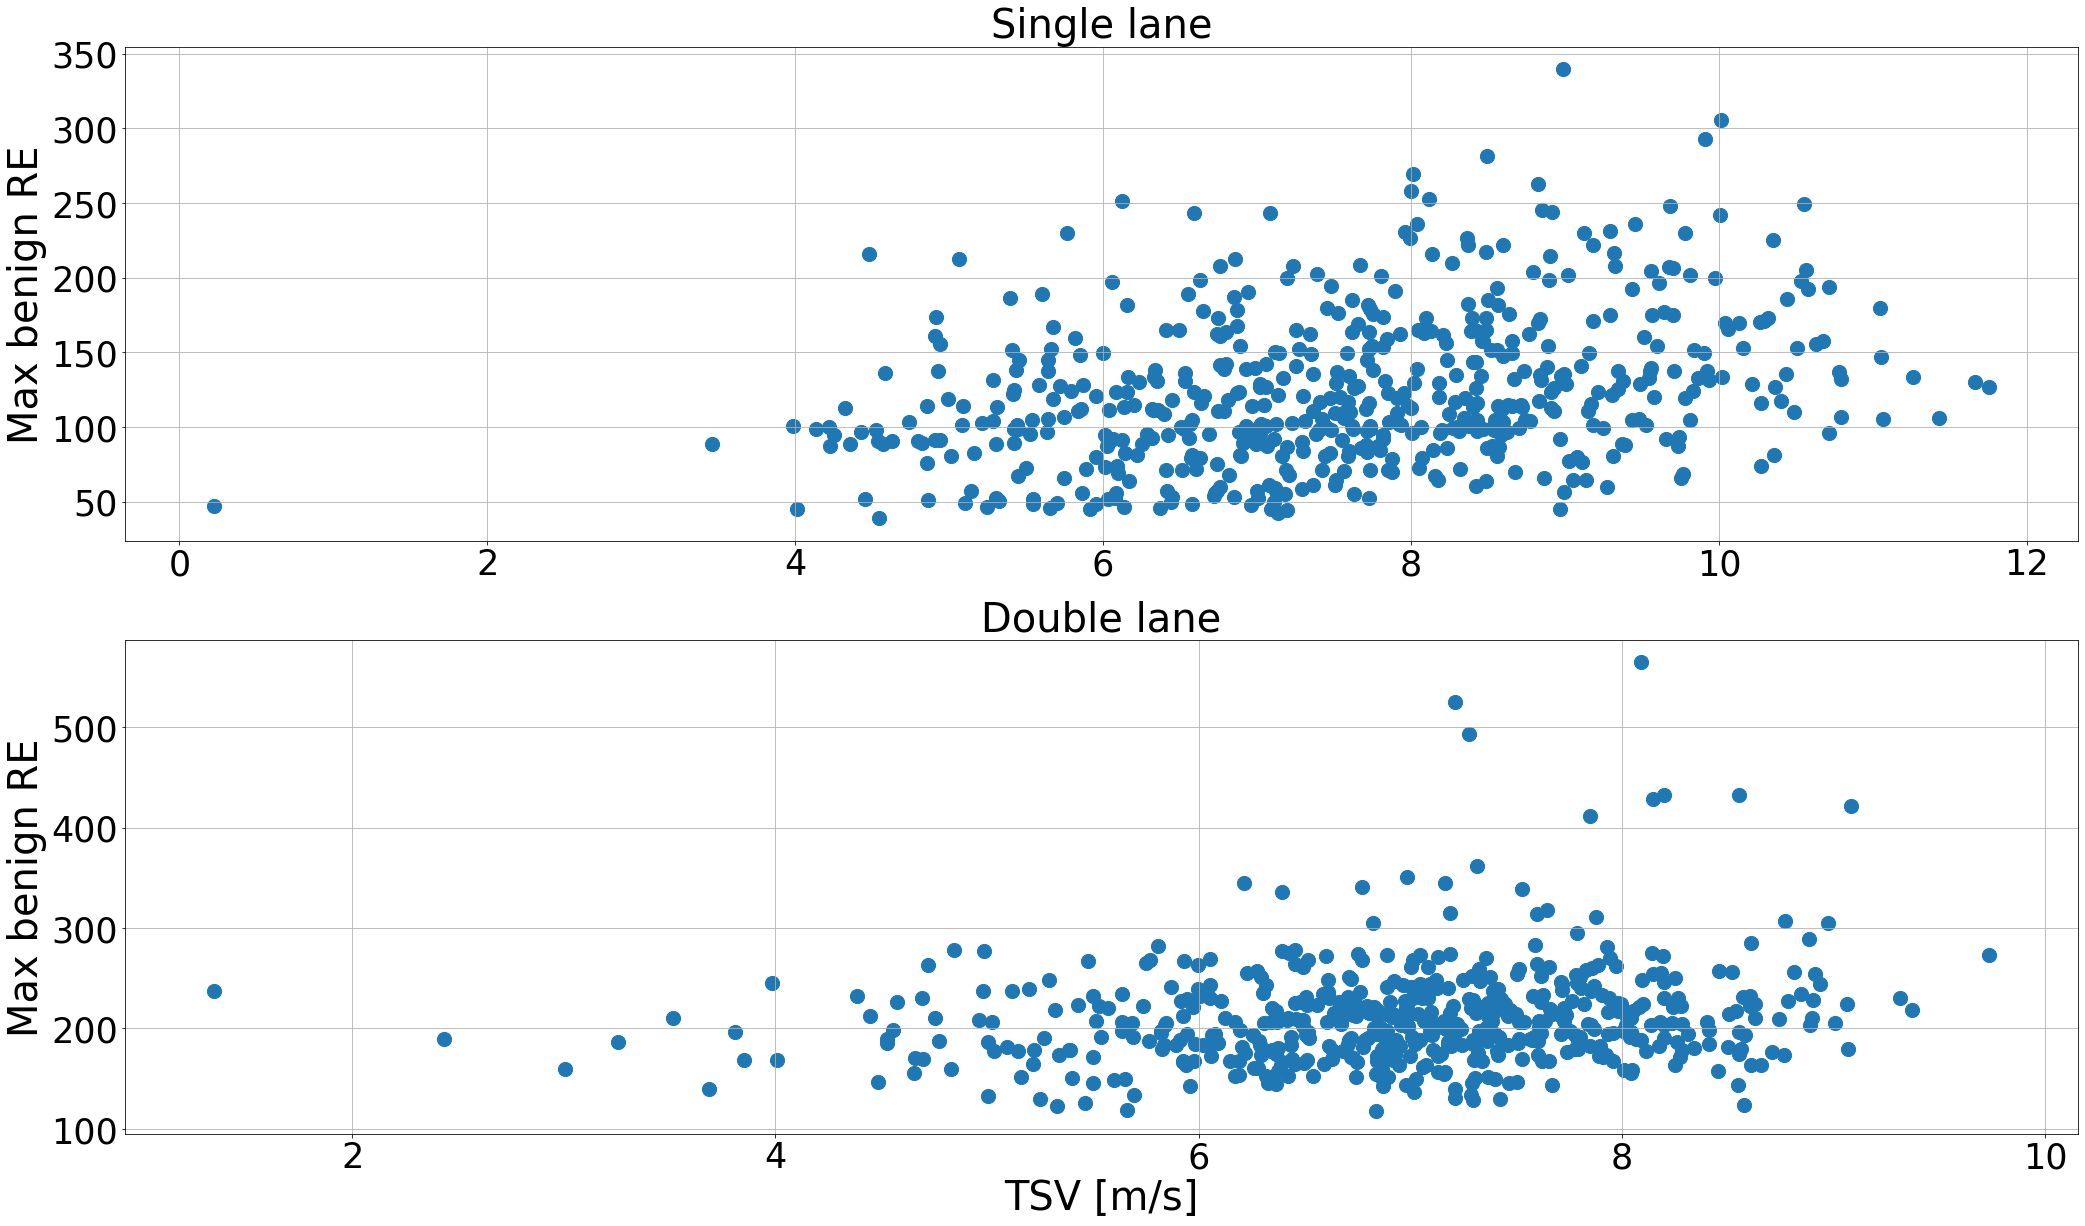

In [161]:
x = TSV_vals_SL_list
y = []

for sim_name in sim_names_SL_list:
    sim_name_key = get_sim_identifier(sim_name[:-4])
    mean_benign_RE = get_max_benign_RE(sim_performance_and_stealth_SL_dict[sim_name_key][sim_name])
    y.append(mean_benign_RE)


plt.figure(figsize=[35,20])

plt.subplot(2,1,1)
plt.scatter(x,y,s=200)
_ = plt.ylabel('Max benign RE',fontsize=LABEL_FONTSIZE)
# _ = plt.xlabel('MTS [m/s]',fontsize=LABEL_FONTSIZE)
_ = plt.yticks(fontsize=TICK_FONTSIZE)
_ = plt.xticks(fontsize=TICK_FONTSIZE)
plt.grid()
# plt.ylim([-1.0,100])
# plt.xlim([4.7,7])
_ = plt.title('Single lane',fontsize=LABEL_FONTSIZE)

x = TSV_vals_DL_list
y = []

for sim_name in sim_names_DL_list:
    sim_name_key = get_sim_identifier(sim_name[:-4])
    mean_benign_RE = get_max_benign_RE(sim_performance_and_stealth_DL_dict[sim_name_key][sim_name])
    y.append(mean_benign_RE)

plt.subplot(2,1,2)
plt.scatter(x,y,s=200)
_ = plt.ylabel('Max benign RE',fontsize=LABEL_FONTSIZE)
_ = plt.xlabel('TSV [m/s]',fontsize=LABEL_FONTSIZE)
_ = plt.yticks(fontsize=TICK_FONTSIZE)
_ = plt.xticks(fontsize=TICK_FONTSIZE)
plt.grid()
# plt.ylim([-1.0,100])
# plt.xlim([4.7,7])
_ = plt.title('Double lane',fontsize=LABEL_FONTSIZE)

# Get MpVRE values for all sims:

In [40]:
max_RE_dict = {}

for i,file_path in enumerate(rec_error_file_paths):
    
    sim_name = sim_names_list[i]
    sim_name_key = get_sim_identifier(sim_names_list[i][:-4])
    RE_data = np.loadtxt(file_path,delimiter=',',dtype=str)
    
    if(sim_name_key not in max_RE_dict.keys()):
        max_RE_dict[sim_name_key] = []
    
    for data in RE_data:
        max_RE_dict[sim_name_key].append(data)
    
    

(0.0, 200.0)

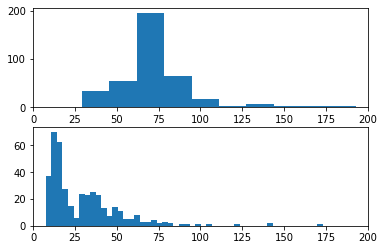

In [65]:
MpVRE_vals_attacked = get_MpVRE_with_label(max_RE_dict['TAD_10.0_ADR_-0.75'])

MpVRE_vals_attacked = np.array(MpVRE_vals_attacked)

#plt.plot(MpVRE_vals_attacked[:,1],MpVRE_vals_attacked[:,0],'.')

plt.subplot(2,1,1)
_ = plt.hist(MpVRE_vals_attacked[:,0],50)
plt.xlim([0,200])

MpVRE_vals_attacked = get_MpVRE_with_label(max_RE_dict['TAD_1.0_ADR_-0.75'])

MpVRE_vals_attacked = np.array(MpVRE_vals_attacked)

#plt.plot(MpVRE_vals_attacked[:,1],MpVRE_vals_attacked[:,0],'.')

plt.subplot(2,1,2)
_ = plt.hist(MpVRE_vals_attacked[:,0],50)
plt.xlim([0,200])

In [49]:
all_no_attack_RE_values = []

sim_name_keys = list(max_RE_dict.keys())

for key in sim_name_keys:
    if('TAD_0.0' in key):
        MpVRE_vals = max_RE_dict[key]
        for MpVRE in MpVRE_vals:
            MpVRE = float(MpVRE[1])
            all_no_attack_RE_values.append(MpVRE)
print('Finished.')

Finished.


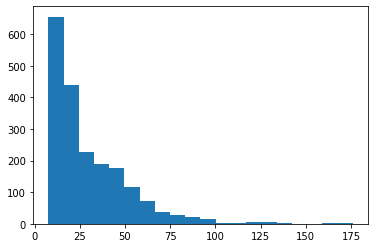

In [53]:
_ = plt.hist(all_no_attack_RE_values,20)